# First practical work in Deep Learning course 
**Name:** Maha Kahla 


**Purpose of the laboratory work:** to study the process of object classification with the help of convolutional neural network on the example 
of kaggle data.

The first thing we have to do is importing the necessary libraries that include the tools we need to implement the tasks

In [1]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import random
import sys
import time
from torchvision import datasets
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import os
from PIL import Image
from torch.utils.data import DataLoader

# import tensorflow as tf
# from torch.utils.tensorboard import SummaryWriter
from IPython.display import clear_output

the next step is to define the hardware accelerator GPU after checking its availability using torch.cuda , otherwise the cpu is used

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


Firstly, I have downloaded the required dataset from kaggle on local machine. which is containing images of vegetables from 15 types. Since the dataset is already splited in a convenient way, and represented in 3 folders: train, validation, test I used the method ImageFolder to get the data.
In order to get the parameters for normalization, I used the following code. It contains calculating the mathematical expectation and standard devaition.

In [3]:
train_dataset = datasets.ImageFolder('archive/Vegetable_Images/train' , transform = T.ToTensor())
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

In [ ]:
#########################

In [4]:
sumel = 0.0
countel = 0
for img, _ in train_dataset:
    sumel += img.sum([1, 2])
    countel += torch.numel(img[0])
mean = sumel/countel
print(mean)

tensor([0.4688, 0.4635, 0.3433])


In [9]:
sumel = 0.0
countel = 0
for img, _ in train_dataset:
    img = (img - mean.unsqueeze(1).unsqueeze(1))**2
    sumel += img.sum([1, 2])
    countel += torch.numel(img[0])
std = torch.sqrt(sumel/countel)
print(std)

tensor([0.2352, 0.2299, 0.2442])


After loading the dataset in the notebook we need to implement some preprocessing transforms. From torchvision I could use some of the transformers. These transformations are typically used for preprocessing or augmenting images in deep learning tasks: Resize the input image to a fixed size if the image has a different aspect ratio. RandomRotation applies a random rotation to the image, within a range of -15 to +15 degrees. This helps in augmenting the dataset by introducing rotations of the image during training, making the model more robust to such transformations. ColorJitter applies random changes in the image’s brightness, contrast, saturation, and hue.  The range for jittering is 10% of the original value. ToTensor converts the image into a PyTorch tensor. and finally Normalize the image tensor by subtracting the given mean and dividing by the given standard deviation for each channel, and making the training more efficient.

In [4]:

transform = T.Compose([
    T.Resize((128, 128)),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.4688, 0.4635, 0.3433], std=[0.2352, 0.2299, 0.2442])
])

After preparing the dataset, we need to set up data loaders for training, validation, and testing datasets using the torchvision.datasets.ImageFolder class and the PyTorch DataLoader. Each dataset (train_dataset, val_dataset, test_dataset) will contain a list of image-label pairs. The DataLoader objects (train_dataloader, val_dataloader, and test_dataloader) will be used during training, validation, and testing, to provide batches of data in an efficient manner.

In [14]:
train_dataset = datasets.ImageFolder('archive/Vegetable_Images/train', transform=transform)
val_dataset = datasets.ImageFolder('archive/Vegetable_Images/validation', transform=transform)
test_dataset = datasets.ImageFolder('archive/Vegetable_Images/test', transform=transform)


batchSize = 32
train_dataloader = DataLoader(train_dataset, batch_size=batchSize, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=batchSize, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=batchSize, shuffle=False, drop_last=True)

To set up a convolutional neural network model, I used the following hyperparameters. Kernel size defines the size of the convolutional filter which slides across the image to apply a convolution operation. and 3x3 is common and helps preserve the spatial resolution of the image while capturing local patterns. A stride of 1 means the filter moves one pixel at a time across the image during the convolution process.it ensures that the resolution of the image is maintained as much as possible during convolution. Padding adds extra pixels around the border of the image to ensure that the output image size remains the same after the convolution. window size for pooling to reduce the spatial dimensions of the feature maps.A learning rate of 0.001 allows the model to learn slowly but steadily, avoiding large jumps in the optimization process. 

In [15]:
img_size = [128, 128]
kernel_size = 3
stride = 1
padding = 1
window_size = 2  
learning_rate = 0.001

I tried different architectures and different hyperparameters and I ended up with these configurations of the convolutional neural network: the model has 5 convolutional layers followed by max pooling and batch normalization. Finally, a fully connected layer for classification.  

*   The first convolutional layer (conv1) has 3 input channels and 64 output channels (feature maps). After this layer, batch normalization (bnorm1) is applied, followed by a max pooling layer.
*   The second convolutional layer (conv2) takes the output from the previous layer (64 channels) and produces 128 output channels. Again, batch normalization (bnorm2) is followed by max pooling.


*   The third convolutional layer (conv3) produces 256 output channels from the 128 input channels. The same batch normalization and max pooling is applied here.
*   The fourth convolutional layer (conv4) outputs 512 channels from the 256 input channels. Batch normalization and max pooling are applied as before.


*   The fifth and final convolutional layer (conv5) produces 512 channels from the 512 input channels. The batch normalization and max pooling are applied similarly.
*   After the convolutional layers and pooling, the output is flattened (reshaped) and passed into a fully connected layer (fc1) with 1024 neurons.


*   The final layer (output) is a fully connected layer with 15 output neurons, which correspond to 15 classes for classification.




In [16]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # layer 1 
        self.conv1 = nn.Conv2d(3, 64, kernel_size, stride, padding)
        self.bnorm1 = nn.BatchNorm2d(64)
        conv1_imgSize = np.floor((img_size[0] + 2*padding - kernel_size) / stride) + 1
        post_pooling_conv1 = np.floor(conv1_imgSize / window_size).astype(int)

        # layer 2
        self.conv2 = nn.Conv2d(64, 128, kernel_size, stride, padding)
        self.bnorm2 = nn.BatchNorm2d(128)
        conv2_imgSize = np.floor((post_pooling_conv1 + 2*padding - kernel_size) / stride) + 1
        post_pooling_conv2 = np.floor(conv2_imgSize / window_size).astype(int)

        # layer 3 
        self.conv3 = nn.Conv2d(128, 256, kernel_size, stride, padding)
        self.bnorm3 = nn.BatchNorm2d(256)
        conv3_imgSize = np.floor((post_pooling_conv2 + 2*padding - kernel_size) / stride) + 1
        post_pooling_conv3 = np.floor(conv3_imgSize / window_size).astype(int)

        # layer 4 
        self.conv4 = nn.Conv2d(256, 512, kernel_size, stride, padding)
        self.bnorm4 = nn.BatchNorm2d(512)
        conv4_imgSize = np.floor((post_pooling_conv3 + 2*padding - kernel_size) / stride) + 1
        post_pooling_conv4 = np.floor(conv4_imgSize / window_size).astype(int)

        # layer 5 
        self.conv5 = nn.Conv2d(512, 512, kernel_size, stride, padding)
        self.bnorm5 = nn.BatchNorm2d(512)
        conv5_imgSize = np.floor((post_pooling_conv4 + 2*padding - kernel_size) / stride) + 1
        post_pooling_conv5 = np.floor(conv5_imgSize / window_size).astype(int)

        # 6

        self.fc1 = nn.Linear(post_pooling_conv5 * post_pooling_conv5 * 512, 1024)
        self.output = nn.Linear(1024, 15)

    def forward(self, x):

        #1
        x = F.relu(self.bnorm1(F.max_pool2d(self.conv1(x), window_size)))
        #2
        x = F.relu(self.bnorm2(F.max_pool2d(self.conv2(x), window_size)))
        #3
        x = F.relu(self.bnorm3(F.max_pool2d(self.conv3(x), window_size)))
        #4
        x = F.relu(self.bnorm4(F.max_pool2d(self.conv4(x), window_size)))
        #5
        x = F.relu(self.bnorm5(F.max_pool2d(self.conv5(x), window_size)))

        
        # Reshaping for linear layer
        x = x.reshape(x.shape[0], -1)
        # 6
        x = F.relu(self.fc1(x))


        return self.output(x)

The following code represents creating an instance of the model and send it to GPU. Cross-entropy loss is typically used for multi-class classification problems. it computes the cross-entropy loss between the predicted probabilities and the true class labels. Adam optimizer is an adaptive learning rate optimizer that is commonly used for training neural networks.

In [17]:
vegetables = NeuralNetwork()
vegetables.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vegetables.parameters(), lr=learning_rate, weight_decay=0.001)

The following part is to make sure the output shape is correct before the real training begins.

In [18]:
imgs, labels = next(iter(train_dataloader))

# print("\nThe first sample in the batch:")
# img = imgs[0].squeeze()
# label = labels[0].item()

# plt.figure(figsize=(3, 3))
# plt.imshow(img.T, cmap="gray")
# plt.title(label)
# plt.axis("off")
# plt.show()

imgs, labels = imgs.to(device), labels.to(device)
pred = vegetables(imgs)
print('Output size:')
print(pred.shape)

loss = criterion(pred,torch.squeeze(labels))
print('Loss:')
print(loss)


Output size:
torch.Size([32, 15])
Loss:
tensor(2.7224, device='cuda:0', grad_fn=<NllLossBackward0>)


Now that we've initialized the model, loss function, and optimizer, we can proceed with the training loop. I have used a basic structure for the training loop using these components:

In [19]:
num_epochs = 12

In [20]:
def train_NN():

    trainLoss = torch.zeros(num_epochs)
    valLoss = torch.zeros(num_epochs)
    trainAcc = torch.zeros(num_epochs)
    valAcc = torch.zeros(num_epochs)
    

    for epochi in range(num_epochs):

        vegetables.train()
        batch_train_loss = []
        batch_train_acc = []
        for imgs, labels in train_dataloader:
            imgs, labels  = imgs.to(device), labels.to(device)

            pred = vegetables(imgs)
            loss = criterion(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_train_loss.append(loss.item())
            batch_train_acc.append(torch.mean((torch.argmax(pred, axis=1) == labels).float()).item())


        trainLoss[epochi] = np.mean(batch_train_loss)
        trainAcc[epochi] = 100 * np.mean(batch_train_acc)

        vegetables.eval()
        with torch.no_grad():
            batch_val_loss = []
            batch_val_acc = []
            for imgs, labels in val_dataloader:
                imgs, labels = imgs.to(device), labels.to(device)


                pred = vegetables(imgs)
                loss = criterion(pred, labels)

                batch_val_loss.append(loss.item())
                batch_val_acc.append(torch.mean((torch.argmax(pred, axis=1) == labels).float()).item())


            valLoss[epochi] = np.mean(batch_val_loss)
            valAcc[epochi] = 100 * np.mean(batch_val_acc)

        sys.stdout.write(f"\rFinished epoch: {epochi+1}/{num_epochs}")

    print("    Done!!!")
    return trainLoss, valLoss, trainAcc, valAcc,  vegetables

Also a similar loop for testing after training has been added

In [21]:
def test_NN():

    with torch.no_grad():
        batch_test_loss = []
        batch_test_acc = []
        for imgs, labels in test_dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            pred = vegetables(imgs)
            loss = criterion(pred, labels)

            batch_test_loss.append(loss.item())
            batch_test_acc.append(torch.mean((torch.argmax(pred, axis=1) == labels).float()).item())

        testLoss = np.mean(batch_test_loss)
        testAcc = 100 * np.mean(batch_test_acc)

    print("Done!!!")
    return testLoss, testAcc

The training was implemented on my local machine with a gpu:

In [22]:
trainLoss, valLoss, trainAcc, valAcc, vegetables = train_NN()

Finished epoch: 12/12    Done!!!


In [23]:
testLoss, testAcc = test_NN()

Done!!!


In [24]:
testAcc

96.30376344086021

The following code is for plotting the training loss and accuracy during training and validation over the epochs. The model achieves high accuracy (~96%) while maintaining low loss. The plotted graphs show successful model convergence.

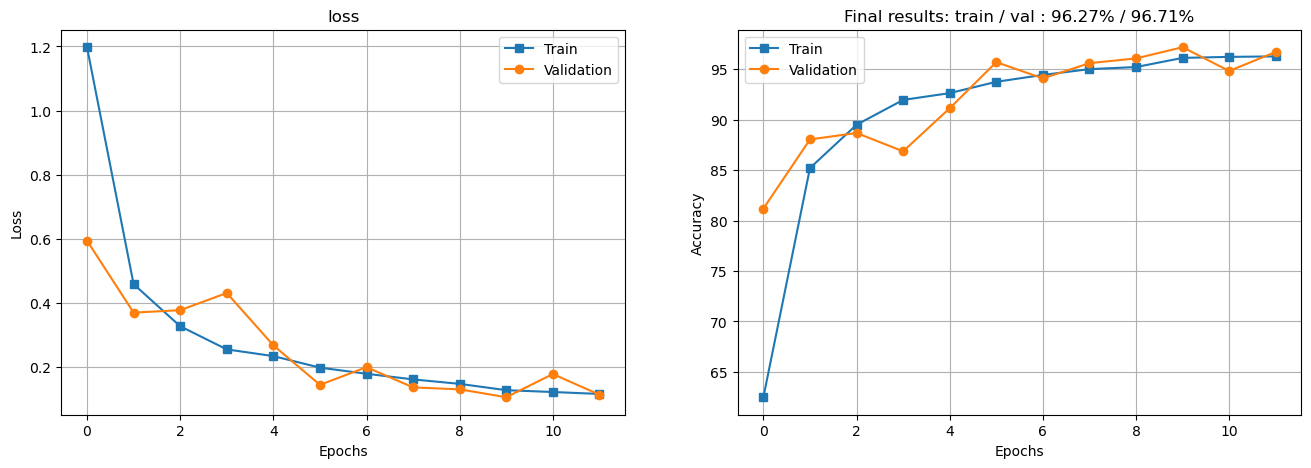

In [25]:
fig, a = plt.subplots(1, 2, figsize=(16, 5))

a[0].plot(trainLoss, 's-', label='Train')
a[0].plot(valLoss, 'o-', label='Validation')

a[0].set_xlabel('Epochs')
a[0].set_ylabel('Loss')
a[0].set_title('loss')
a[0].legend()
a[0].grid(True)

a[1].plot(trainAcc, 's-', label='Train')
a[1].plot(valAcc, 'o-', label='Validation')
a[1].set_xlabel('Epochs')
a[1].set_ylabel('Accuracy')
a[1].set_title(f'Final results: train / val : {trainAcc[-1]:.2f}% / {valAcc[-1]:.2f}%')
a[1].legend()
a[1].grid(True)

plt.show()

Saving the weight of the trained model

In [26]:
torch.save(vegetables.state_dict(), "model_weights.pth")

The following part is showing using the trained model to make predictions for a batch of images.

In [27]:
model = NeuralNetwork()
model.load_state_dict(torch.load("model_weights.pth"))
model.to(device)
print(model)

NeuralNetwork(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=8192, out_features=1024, bias=True)
  (output): Linear(in_features=1024, out_features=15, bias=True)
)

In [58]:
test_dataloader = DataLoader(test_dataset, batch_size=batchSize, shuffle=True, drop_last=True)

In [59]:
imgs, labels = next(iter(test_dataloader))

print("imgs shape: ", imgs.shape)


imgs shape:  torch.Size([32, 3, 128, 128])


In [60]:
# get output
pred = model(imgs.to(device))
print("pred shape: ", pred.shape)

pred shape:  torch.Size([32, 15])


In [61]:
import numpy as np

pred = pred[:10].detach()
print("Prediction(1 sample):\n", pred[0])

digits = np.argmax(pred.cpu().numpy(), axis=1)
print("Predicted class: ", digits[0])

Prediction(1 sample):
 tensor([ -6.3185,  -5.1300,  -1.3148,  -5.8522, -10.3635,  -7.4512,  -5.8668,
          8.6796,  -6.9739,  -1.9163,  -2.5280,  -2.2154,   0.8003,  -4.7129,
         -4.1315], device='cuda:0')
Predicted class:  7


In [62]:
# remove axis
imgs = torch.squeeze(imgs)
print("imgs shape (after squeeze): ", imgs.shape)

# take 10 first images
imgs = imgs[:10]
print("imgs shape: ", imgs.shape)

imgs shape (after squeeze):  torch.Size([32, 3, 128, 128])
imgs shape:  torch.Size([10, 3, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.016094..2.2585034].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8796322..1.902306].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8796322..2.111071].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.016094..1.6854302].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8796322..1.7256588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8796322..1.8389497].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.016094..2.

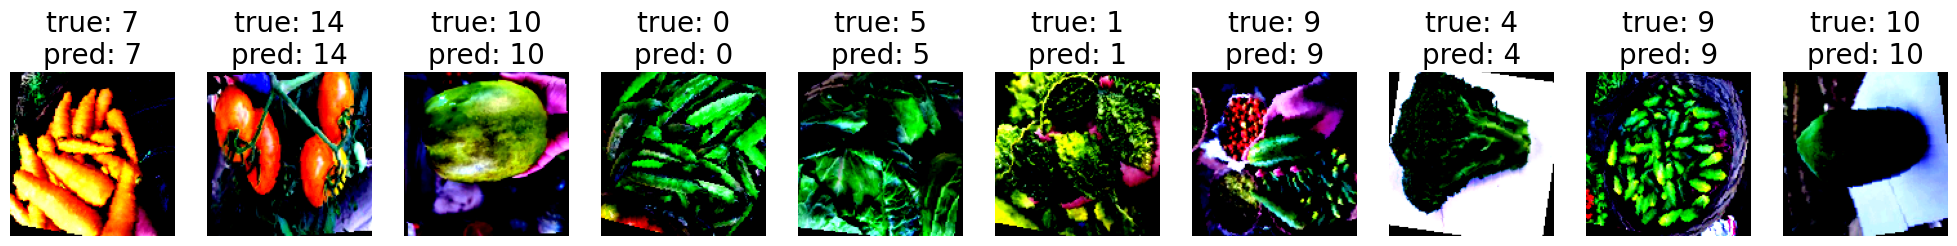

In [63]:
plt.figure(figsize=(25.0, 25.0))
for i in range(10):
    img = imgs[i]

    plt.subplot(1, 10, i + 1)
    plt.title(
        f"true: {labels[i].numpy()}\npred: {digits[i]}", fontsize=20
    )  # predicted and real values
    plt.axis("off")
    plt.imshow(img.T, cmap="gray")